In [142]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')


In [143]:
# import the dataset
power_plant = pd.read_csv('/content/powerplant_data.csv')
df = power_plant.copy()
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [144]:
# basic details about the data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [145]:
df.describe()

,AT,V,AP,RH,PE
count,9568.000000,9568.000000,9568.000000,9568.000000,9568.000000
mean,19.651231,54.305804,1013.259078,73.308978,454.365009
std,7.452473,12.707893,5.938784,14.600269,17.066995
min,1.810000,25.360000,992.890000,25.560000,420.260000
25%,13.510000,41.740000,1009.100000,63.327500,439.750000
50%,20.345000,52.080000,1012.940000,74.975000,451.550000
75%,25.720000,66.540000,1017.260000,84.830000,468.430000
max,37.110000,81.560000,1033.300000,100.160000,495.760000


Features with the null values: 
 AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64


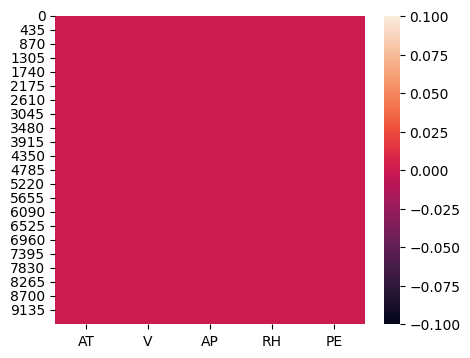

In [146]:
plt.figure(figsize=(5,4))
sns.heatmap(df.isnull())
print("Features with the null values: \n",df.isnull().sum())

<Axes: >

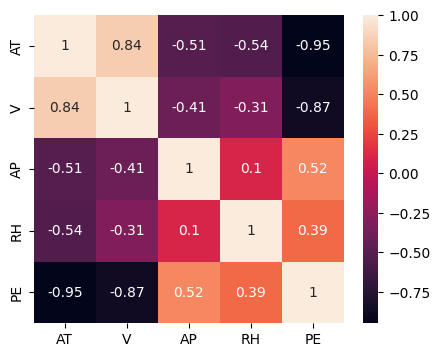

In [147]:
# correlation between the columns
plt.figure(figsize=(5,4))
sns.heatmap(df.corr(), annot=True)

In [148]:
# split the data
X=df.drop("PE",axis=1)
y=df["PE"]

# train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(X_train.shape)
print(y_train.shape)

(7654, 4)
(7654,)


In [149]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)
print(X_train_scaled)

[[ 0.74805289  0.72006931 -0.32660017 -0.49711722]
 [ 0.86181948  1.26515721 -0.98521113  0.8181501 ]
 [ 0.93409473  1.52314975  0.32523844  0.80167494]
 ...
 [-0.22097078 -0.834965    0.36756563 -0.83554456]
 [ 0.94747903  1.14245344 -0.41971997 -0.45455637]
 [-1.77355014 -1.19049131  1.92520594  0.91837402]]


In [150]:
import torch
import torch.nn as nn

X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [151]:
print(X_train_tensor)
print(X_test_tensor)

tensor([[ 0.7481,  0.7201, -0.3266, -0.4971],
        [ 0.8618,  1.2652, -0.9852,  0.8182],
        [ 0.9341,  1.5231,  0.3252,  0.8017],
        ...,
        [-0.2210, -0.8350,  0.3676, -0.8355],
        [ 0.9475,  1.1425, -0.4197, -0.4546],
        [-1.7736, -1.1905,  1.9252,  0.9184]])
tensor([[ 1.3450,  0.2387, -1.2866, -1.1053],
        [ 0.8110,  1.3627, -0.7414,  0.2649],
        [-0.2437, -0.7390,  1.9997, -0.1971],
        ...,
        [-0.6707, -1.1590, -0.2995, -0.1065],
        [ 1.3142,  1.3375, -0.8735, -0.4429],
        [-0.2611, -0.2702,  0.3743,  1.1065]])


In [152]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [153]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)
train_loader

## ANN


In [154]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()
        self.model=nn.Sequential(
            #1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            #2nd
            nn.Linear(6,6),
            nn.ReLU(),

            #output
            nn.Linear(6,1),
        )
    def forward(self,x):
        return self.model(x)

In [155]:
import torch.optim as optim

ann_model=ANN()
#loss,optimizer
crietrion=nn.MSELoss()
optimizer=optim.Adam(ann_model.parameters())

In [156]:
train_losses=[]
val_losses=[]

best_val_loss=float("inf")

epochs=100
for epoch in range(epochs):
    ann_model.train()
    running_loss=0.0  # tot training loss for 1 epoch

    for xb,yb in train_loader:
        optimizer.zero_grad()
        outputs=ann_model(xb)
        loss=crietrion(outputs,yb)
        loss.backward()
        optimizer.step()
        running_loss+=loss.item()
    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)

    #eval
    ann_model.eval()
    running_val_loss=0.0

    with torch.no_grad():
        for xb,yb in test_loader:
            outputs=ann_model(xb)
            loss=crietrion(outputs,yb)
            running_val_loss+=loss.item()
    epoch_val_loss=running_val_loss/len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs}==> train loss = {epoch_train_loss} & val loss={epoch_val_loss}")

    if epoch_val_loss<best_val_loss:
        best_val_loss=epoch_val_loss
        torch.save(ann_model.state_dict(),"best_model.pt")

epoch 1/100==> train loss = 205684.65540364583 & val loss=202470.63619791667
epoch 2/100==> train loss = 192540.2771484375 & val loss=176984.31770833334
epoch 3/100==> train loss = 151722.72278645833 & val loss=122127.62942708333
epoch 4/100==> train loss = 91187.24612630208 & val loss=62470.88971354167
epoch 5/100==> train loss = 43559.635522460936 & val loss=30283.5498046875
epoch 6/100==> train loss = 24570.084834798177 & val loss=20896.07198893229
epoch 7/100==> train loss = 18666.3946879069 & val loss=16738.149869791665
epoch 8/100==> train loss = 15014.717952473959 & val loss=13261.18740234375
epoch 9/100==> train loss = 11687.862111409506 & val loss=10110.673763020834
epoch 10/100==> train loss = 8789.48364868164 & val loss=7381.9931640625
epoch 11/100==> train loss = 6234.844352213541 & val loss=5120.9532755533855
epoch 12/100==> train loss = 4235.600014241537 & val loss=3396.934391276042
epoch 13/100==> train loss = 2748.916857147217 & val loss=2161.321001180013
epoch 14/100==

In [157]:
best_val_loss

18.641981689135232

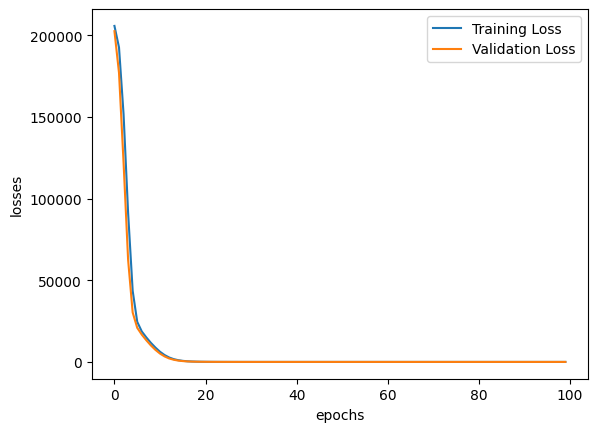

In [158]:
loss_df=pd.DataFrame({
    "Training Loss":train_losses,
    "Validation Loss":val_losses
})

plt.plot(loss_df["Training Loss"],label="Training Loss")
plt.plot(loss_df["Validation Loss"],label="Validation Loss")

plt.xlabel("epochs")
plt.ylabel("losses")
plt.legend()

In [159]:
ann_model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [160]:
ann_model.eval()
with torch.no_grad():
    train_preds=ann_model(X_train_tensor)
    test_preds=ann_model(X_test_tensor)

    train_mse_loss=crietrion(train_preds,y_train_tensor)
    test_mse_loss=crietrion(test_preds,y_test_tensor)
print("Training MSE: ",train_mse_loss.item())
print("Testing MSE: ",test_mse_loss.item())

Training MSE:  20.309539794921875
Testing MSE:  18.646793365478516


In [161]:
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error
r2_score_ann=r2_score(y_test,test_preds)
mae_score_ann=mean_absolute_error(y_test,test_preds)
rmse_score_ann=np.sqrt(mean_squared_error(y_test,test_preds))
print("r2_score: ",r2_score_ann)
print("MAE score: ",mae_score_ann)
print("RMSE score: ",rmse_score_ann)

r2_score:  0.9348342700286107
MAE score:  3.4353799250332666
RMSE score:  4.31819301281268


In [162]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])
actual_df=pd.DataFrame(y_test.values,columns=["Actual Values"])

pd.concat([predicted_df,actual_df],axis=1)

,Predicted Values,Actual Values
0,435.329224,433.27
1,436.830719,438.16
2,461.332886,458.42
3,476.243347,480.82
4,435.322784,441.41
...,...,...
1909,451.358765,456.70
1910,431.611908,438.04
1911,467.652588,467.80
1912,431.011353,437.14


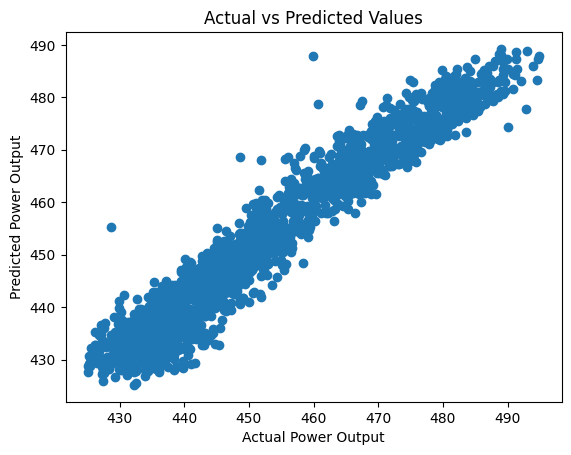

In [163]:
plt.scatter(y_test, test_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

## Other ML Model


In [164]:
df
X=df.drop("PE",axis=1)
y=df["PE"]
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)


In [165]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

### Linear Regression(BaseModel)

In [166]:
from sklearn.linear_model import LinearRegression

lr_model=LinearRegression()
lr_model.fit(X_train_scaled,y_train)
y_preds=lr_model.predict(X_test_scaled)
y_preds_train=lr_model.predict(X_train_scaled)
print("Testing R2_score: ",r2_score(y_test,y_preds))
print("Training R2_score: ",r2_score(y_train,y_preds_train))

Testing R2_score:  0.931474793667036
Training R2_score:  0.9279951490925766


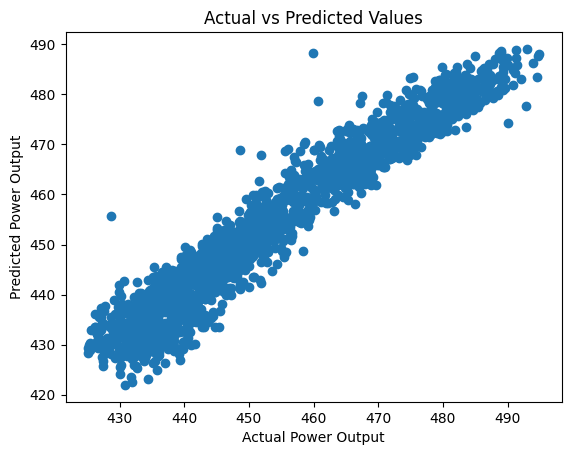

In [167]:
plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

### Random-Forest-Regressor

         AT      V       AP     RH
5487  25.24  63.47  1011.30  66.21
3522  26.09  70.40  1007.41  85.37
6916  26.63  73.68  1015.15  85.13
7544  32.06  71.85  1007.90  56.44
7600  28.70  71.64  1007.11  69.85
(7654, 4)
Testing R2_score:  0.9522567792919476
Training R2_score:  0.9578652221982842


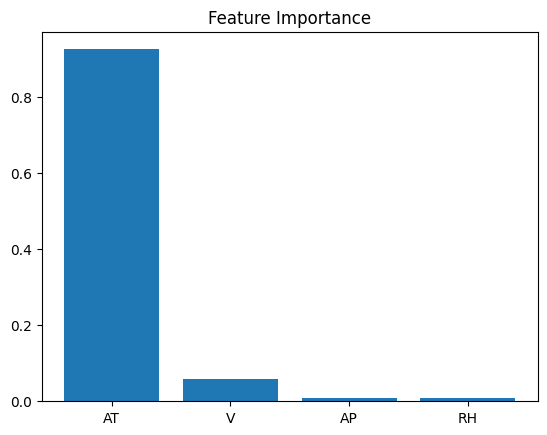

In [168]:
from sklearn.ensemble import RandomForestRegressor
rf_model=RandomForestRegressor(n_estimators=100,max_depth=7,min_samples_split=6)
rf_model.fit(X_train,y_train)

y_preds=rf_model.predict(X_test)
y_preds_train=rf_model.predict(X_train)

print(X_train.head())
print(X_train.shape)

print("Testing R2_score: ",r2_score(y_test,y_preds))
print("Training R2_score: ",r2_score(y_train,y_preds_train))

importances = rf_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

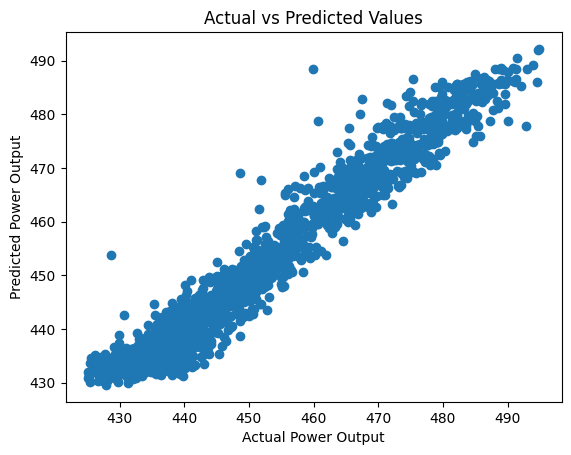

In [169]:
plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

# Gradient-Boosting-Regressor


Training R2 Score:  0.9526149149621398
Testing R2 Score:  0.9514453856425775


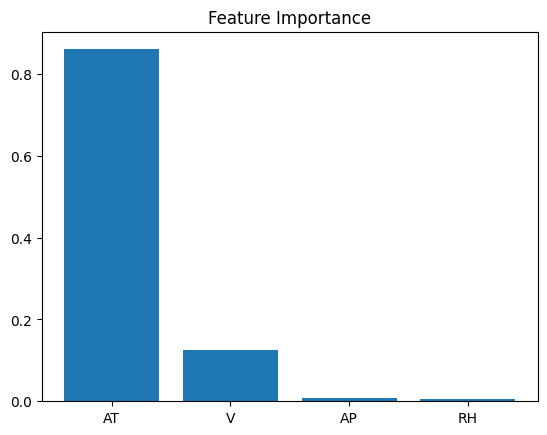

In [170]:
from sklearn.ensemble import GradientBoostingRegressor
gb_model=GradientBoostingRegressor()
gb_model.fit(X_train_scaled,y_train)
y_preds_train=gb_model.predict(X_train_scaled)
y_preds_test=gb_model.predict(X_test_scaled)
print("Training R2 Score: ",r2_score(y_train,y_preds_train))
print("Testing R2 Score: ",r2_score(y_test,y_preds_test))
importances = gb_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

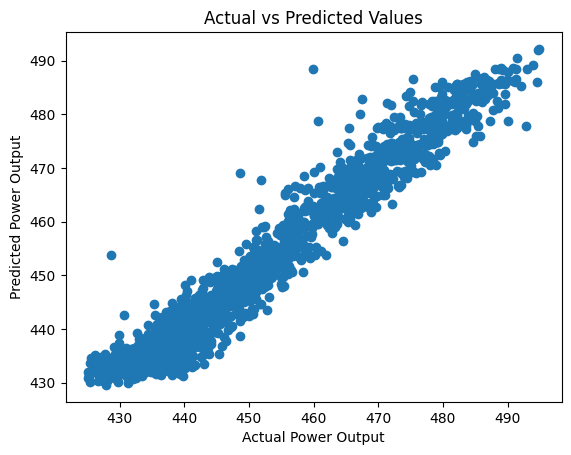

In [171]:
plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

### XGBoost-Regressor

         AT      V       AP     RH
5487  25.24  63.47  1011.30  66.21
3522  26.09  70.40  1007.41  85.37
6916  26.63  73.68  1015.15  85.13
7544  32.06  71.85  1007.90  56.44
7600  28.70  71.64  1007.11  69.85
(7654, 4)
Training R2 Score:  0.9799466846146611
Testing R2 Score:  0.9657424353180492


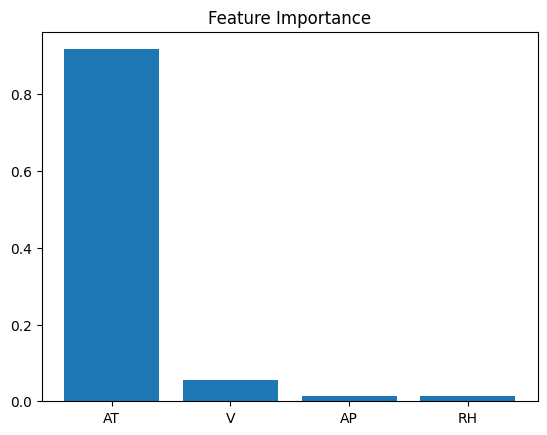

In [172]:
from xgboost import XGBRegressor
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
print(X_train.head())
print(X_train.shape)

xgb_model.fit(X_train,y_train)

y_preds_train=xgb_model.predict(X_train)
y_preds_test=xgb_model.predict(X_test)

print("Training R2 Score: ",r2_score(y_train,y_preds_train))
print("Testing R2 Score: ",r2_score(y_test,y_preds_test))

importances = xgb_model.feature_importances_

plt.bar(X.columns, importances)
plt.title("Feature Importance")
plt.show()

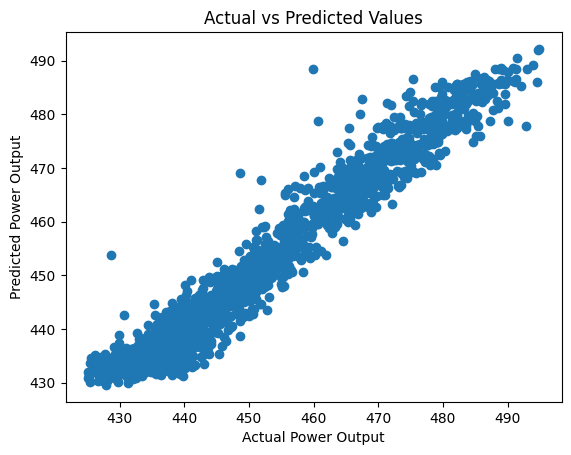

In [173]:
plt.scatter(y_test, y_preds)
plt.xlabel("Actual Power Output")
plt.ylabel("Predicted Power Output")
plt.title("Actual vs Predicted Values")
plt.show()

### SVM

In [174]:
from sklearn.svm import SVR
svm_model=SVR(kernel="rbf")
svm_model.fit(X_train_scaled,y_train)

y_preds_train=svm_model.predict(X_train_scaled)
y_preds_test=svm_model.predict(X_test_scaled)

print("Training R2 Score: ",r2_score(y_train,y_preds_train))
print("Testing R2 Score: ",r2_score(y_test,y_preds_test))


Training R2 Score:  0.9403984549767179
Testing R2 Score:  0.943254533099243


## Evaluation Metrics


In [175]:
from sklearn.metrics import mean_absolute_error,mean_squared_error

models={
    "Linear Regression: ":lr_model,
    "Random Forest":rf_model,
    "Gradient Boosting":gb_model, # Use the tuned gb_model
    "XG Boost":xgb_model,
    "SVM":svm_model,
    "ANN":ann_model

}

results=[]
for name,model in models.items():
    if name=="ANN":
        results.append([name,r2_score_ann,mae_score_ann,rmse_score_ann])
        continue
    if name in ["Random Forest", "XG Boost"]:
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test_scaled)
    r2=r2_score(y_test,y_pred)
    mae=mean_absolute_error(y_test,y_pred)
    rmse=np.sqrt(mean_squared_error(y_test,y_pred))
    results.append([name,r2,mae,rmse])

result_df=pd.DataFrame(results,columns=["Model","R2","MAE","RMSE"])
result_df.set_index("Model")

,R2,MAE,RMSE
Model,,,
Linear Regression:,0.931475,3.543448,4.428102
Random Forest,0.952257,2.819705,3.696139
Gradient Boosting,0.951445,2.869884,3.727414
XG Boost,0.965742,2.264589,3.130911
SVM,0.943255,3.098084,4.029564
ANN,0.934834,3.435380,4.318193


In [176]:
import pickle

pickle.dump(xgb_model, open("power_model.pkl", "wb"))